# Étape 1 — Importez les données et explorez le jeu de radiographies

**Projet 10** — Labellisez et appliquez des approches semi-supervisées en traitement d'images  
**Auteur :** David MEDRAGH — Mai 2026

---

## Objectif

Dans cette première étape, j'explore le jeu de données d'IRM cérébrales fourni par CurelyticsIA. Mon objectif est de dresser un inventaire complet du dataset, de vérifier l'intégrité technique de chaque image, d'identifier les écarts entre la documentation et le contenu réel, et de produire des visualisations représentatives.

## Rappel de la mission

Je suis Data Scientist junior chez CurelyticsIA. Je dispose d'un ensemble d'IRM cérébrales : 100 images labellisées (50 cancer, 50 normal) et environ 1 400 images non étiquetées. Mon rôle est d'explorer ce dataset avant d'en extraire des features, d'appliquer du clustering puis une méthode semi-supervisée.

## Definition of done

- [ ] J'ai un tableau récapitulatif des sous-dossiers et du nombre d'images
- [ ] J'ai vérifié que toutes les images sont lisibles (aucune corrompue)
- [ ] J'ai vérifié résolution, format et canaux sur l'intégralité du dataset
- [ ] J'ai vérifié l'absence de doublons entre dossiers
- [ ] J'ai documenté les écarts entre l'énoncé et le dataset réel
- [ ] J'ai au moins une visualisation d'exemples par catégorie (via torchvision)
- [ ] J'ai rédigé des observations claires pour préparer l'étape 2

## Stack technique

![Stack technique — Étape 1](doc/png/stack_technique_notebook_etape1.png)

## Imports et versions

Je charge les bibliothèques nécessaires à cette exploration :
- **PIL (Pillow)** : ouverture, vérification et inspection technique des images
- **torchvision** : chargement structuré via `ImageFolder` et visualisation d'échantillons
- **pandas / numpy / matplotlib** : manipulation de données tabulaires et affichage

In [2]:
# Suppression des avertissements non critiques pour un affichage propre
import warnings
warnings.filterwarnings('ignore')

# --- Bibliothèques standard ---
import os
from pathlib import Path          # Manipulation de chemins de fichiers (cross-platform)
from collections import Counter   # Comptage d'occurrences (extensions, modes, etc.)

# --- Bibliothèques scientifiques ---
import numpy as np                # Manipulation de tableaux numériques
import pandas as pd               # DataFrames pour les tableaux récapitulatifs
import matplotlib.pyplot as plt   # Visualisation graphique

# --- Traitement d'images ---
from PIL import Image             # Ouverture, vérification et inspection des images

# --- Deep Learning / Vision ---
import torch
import torchvision
from torchvision import transforms            # Transformations (resize, to_tensor)
from torchvision.datasets import ImageFolder  # Chargement structuré par dossiers
from torchvision.io import read_image         # Lecture directe en tenseur
from torchvision.utils import make_grid       # Grille d'images pour affichage

# Affichage des versions pour traçabilité et reproductibilité
print(f"PyTorch : {torch.__version__}")
print(f"torchvision : {torchvision.__version__}")
print(f"NumPy : {np.__version__}")
print(f"pandas : {pd.__version__}")

PyTorch : 2.11.0+cu130
torchvision : 0.26.0+cu130
NumPy : 2.4.4
pandas : 3.0.3


## Définition des chemins

Je définis les chemins vers les trois sous-dossiers du dataset et je vérifie leur existence. Cette centralisation me permet de référencer les dossiers de manière cohérente dans tout le notebook.

In [3]:
# Racine du dataset (chemin relatif depuis le notebook)
DATA_ROOT = Path("data/mri_dataset_brain_cancer_oc")

# Sous-dossiers : images labellisées (cancer et normal) + images sans label
DIR_CANCER = DATA_ROOT / "avec_labels" / "cancer"
DIR_NORMAL = DATA_ROOT / "avec_labels" / "normal"
DIR_SANS_LABEL = DATA_ROOT / "sans_label"

# Dictionnaire centralisé pour itérer facilement sur les 3 dossiers
DOSSIERS = {
    "cancer": DIR_CANCER,
    "normal": DIR_NORMAL,
    "sans_label": DIR_SANS_LABEL,
}

# Vérification que tous les dossiers existent (arrêt immédiat sinon)
for nom, chemin in DOSSIERS.items():
    assert chemin.exists(), f"Dossier manquant : {chemin}"
    print(f"{nom:12s} → {chemin}")

cancer       → data/mri_dataset_brain_cancer_oc/avec_labels/cancer
normal       → data/mri_dataset_brain_cancer_oc/avec_labels/normal
sans_label   → data/mri_dataset_brain_cancer_oc/sans_label


## Inventaire du dataset

Je parcours chaque sous-dossier pour compter les fichiers, recenser les extensions rencontrées, et vérifier que chaque image est lisible (non corrompue). J'utilise `PIL.Image.verify()` qui détecte les fichiers tronqués ou malformés sans charger l'image en mémoire.

In [4]:
# Liste pour stocker les résultats d'inventaire de chaque dossier
inventaire = []

for nom, chemin in DOSSIERS.items():
    # Lister tous les éléments du dossier, triés par nom
    fichiers = sorted(chemin.iterdir())

    # Compter les extensions rencontrées (ex. {'.jpg': 50})
    extensions = Counter(f.suffix.lower() for f in fichiers if f.is_file())
    nb_fichiers = sum(1 for f in fichiers if f.is_file())

    # Tester la lisibilité de chaque image avec PIL.verify()
    # verify() détecte les fichiers tronqués ou malformés sans charger les pixels
    lisibles = 0
    corrompus = []
    for f in fichiers:
        if not f.is_file():
            continue
        try:
            img = Image.open(f)
            img.verify()  # Vérification sans décodage complet
            lisibles += 1
        except Exception as e:
            corrompus.append((f.name, str(e)))

    # Stocker les résultats pour ce dossier
    inventaire.append({
        "dossier": nom,
        "nb_fichiers": nb_fichiers,
        "extensions": dict(extensions),
        "lisibles": lisibles,
        "corrompus": len(corrompus),
        "details_corrompus": corrompus,
    })

    # Affichage des résultats par dossier
    print(f"\n--- {nom} ---")
    print(f"  Fichiers      : {nb_fichiers}")
    print(f"  Extensions    : {dict(extensions)}")
    print(f"  Lisibles      : {lisibles}")
    print(f"  Corrompus     : {len(corrompus)}")
    if corrompus:
        for fname, err in corrompus:
            print(f"    ⚠ {fname} : {err}")

# Bilan global
total = sum(item["nb_fichiers"] for item in inventaire)
print(f"\n{'='*40}")
print(f"Total images : {total}")


--- cancer ---
  Fichiers      : 50
  Extensions    : {'.jpg': 50}
  Lisibles      : 50
  Corrompus     : 0

--- normal ---
  Fichiers      : 50
  Extensions    : {'.jpg': 50}
  Lisibles      : 50
  Corrompus     : 0

--- sans_label ---
  Fichiers      : 1406
  Extensions    : {'.jpg': 1406}
  Lisibles      : 1406
  Corrompus     : 0

Total images : 1506


## Vérification des doublons

Je vérifie qu'aucun nom de fichier n'est partagé entre les trois dossiers. Des doublons pourraient fausser l'analyse en comptant deux fois la même image, ou indiquer une erreur dans la constitution du dataset.

In [5]:
# Collecter les noms de fichiers de chaque dossier dans des ensembles (sets)
noms_par_dossier = {}
for nom, chemin in DOSSIERS.items():
    noms_par_dossier[nom] = set(f.name for f in chemin.iterdir() if f.is_file())

# Comparer chaque paire de dossiers pour détecter des noms communs
dossiers_noms = list(noms_par_dossier.keys())
doublons_trouves = False

for i in range(len(dossiers_noms)):
    for j in range(i + 1, len(dossiers_noms)):
        d1, d2 = dossiers_noms[i], dossiers_noms[j]
        # Intersection des deux ensembles = fichiers portant le même nom
        communs = noms_par_dossier[d1] & noms_par_dossier[d2]
        if communs:
            doublons_trouves = True
            print(f"⚠ Doublons entre {d1} et {d2} : {len(communs)} fichier(s)")
            for c in sorted(communs)[:5]:  # Afficher au max 5 exemples
                print(f"  - {c}")
        else:
            print(f"✓ Aucun doublon entre {d1} et {d2}")

if not doublons_trouves:
    print("\n✓ Tous les noms de fichiers sont uniques entre les 3 dossiers.")

✓ Aucun doublon entre cancer et normal
✓ Aucun doublon entre cancer et sans_label
✓ Aucun doublon entre normal et sans_label

✓ Tous les noms de fichiers sont uniques entre les 3 dossiers.


## Écarts entre l'énoncé et le contenu réel du dataset

| Critère | Énoncé (fichier descriptif) | Réel (contenu du dépôt) | Commentaire |
|---------|----------------------------|------------------------|--------------|
| Format des images | Le courriel de mission mentionne « PNG » | Toutes les images sont en `.jpg` (JPEG) | Le fichier descriptif du dataset confirme le format JPEG — l'incohérence vient du courriel |
| Images non étiquetées | 1 400 | 1 406 | +6 images par rapport à l'annonce |
| Total images | 1 500 | 1 506 | Écart cohérent avec le surplus de non étiquetées |
| Métadonnées séparées | Non mentionnées | Absentes | Pas de fichier CSV de labels ; la structure de dossiers fait office de labellisation |

Ces écarts sont documentés et n'empêchent pas l'analyse. Je retiens les chiffres réels (1 506 images) pour la suite.

## Justification du scan complet

Le dataset contient 1 506 images de 512×512 pixels en JPEG. C'est une volumétrie faible : le scan exhaustif de toutes les images prend quelques secondes et me permet de garantir la qualité de chaque image sans recourir à un échantillonnage. Je choisis donc de vérifier les dimensions, le mode couleur et la lisibilité de **l'intégralité** du dataset plutôt que d'un sous-ensemble.

In [6]:
# Scan exhaustif : pour chaque image, je relève dimensions, mode couleur et format
records = []

for nom, chemin in DOSSIERS.items():
    for f in sorted(chemin.iterdir()):
        if not f.is_file():
            continue
        try:
            img = Image.open(f)
            # Enregistrer les métadonnées techniques de l'image
            records.append({
                "dossier": nom,
                "fichier": f.name,
                "largeur": img.width,       # Largeur en pixels
                "hauteur": img.height,      # Hauteur en pixels
                "mode": img.mode,           # Mode couleur : L (gris), RGB, RGBA...
                "format": img.format,       # Format de fichier : JPEG, PNG...
                "erreur": None,
            })
        except Exception as e:
            # Si l'image ne peut pas être ouverte, je trace l'erreur
            records.append({
                "dossier": nom,
                "fichier": f.name,
                "largeur": None,
                "hauteur": None,
                "mode": None,
                "format": None,
                "erreur": str(e),
            })

# Construire le DataFrame avec une ligne par image
df_images = pd.DataFrame(records)
print(f"Images analysées : {len(df_images)}")
print(f"Images en erreur  : {df_images['erreur'].notna().sum()}")

# Distribution des dimensions (je m'attends à 100% de 512×512)
print("\n--- Dimensions ---")
print(df_images.groupby(["largeur", "hauteur"]).size().reset_index(name="count"))

# Distribution des modes couleur (L = niveaux de gris, RGB = couleur)
print("\n--- Modes couleur ---")
print(df_images["mode"].value_counts())

# Distribution des formats de fichier
print("\n--- Formats ---")
print(df_images["format"].value_counts())

Images analysées : 1506
Images en erreur  : 0

--- Dimensions ---
   largeur  hauteur  count
0      512      512   1506

--- Modes couleur ---
mode
RGB    1506
Name: count, dtype: int64

--- Formats ---
format
JPEG    1506
Name: count, dtype: int64


## Tableau récapitulatif

Je construis un DataFrame de synthèse par dossier : nombre d'images, dimensions, modes couleur, formats et anomalies éventuelles. Ce tableau me donne une vision consolidée de l'homogénéité du dataset.

In [7]:
# Tableau récapitulatif par dossier
recap = df_images.groupby("dossier").agg(
    nb_images=("fichier", "count"),
    dimensions=("largeur", lambda x: f"{x.iloc[0]}×{df_images.loc[x.index, 'hauteur'].iloc[0]}" if x.nunique() == 1 else "mixte"),
    modes=("mode", lambda x: ", ".join(sorted(x.unique()))),
    formats=("format", lambda x: ", ".join(sorted(x.dropna().unique()))),
    erreurs=("erreur", lambda x: x.notna().sum()),
).reset_index()

# Vérifier s'il y a des anomalies de dimensions
dims_non_standard = df_images[(df_images["largeur"] != 512) | (df_images["hauteur"] != 512)]
if len(dims_non_standard) > 0:
    print(f"⚠ {len(dims_non_standard)} image(s) avec des dimensions non standard :")
    print(dims_non_standard[["dossier", "fichier", "largeur", "hauteur"]])
else:
    print("✓ Toutes les images sont en 512×512 pixels.")

print("\n--- Récapitulatif par dossier ---")
recap

✓ Toutes les images sont en 512×512 pixels.

--- Récapitulatif par dossier ---


,dossier,nb_images,dimensions,modes,formats,erreurs
0,cancer,50,512×512,RGB,JPEG,0
1,normal,50,512×512,RGB,JPEG,0
2,sans_label,1406,512×512,RGB,JPEG,0


## Échantillon visuel

Je charge et affiche 5 images par catégorie (cancer, normal, sans_label) pour avoir un aperçu visuel représentatif du dataset. J'utilise `torchvision.datasets.ImageFolder` pour les images labellisées (qui bénéficient de la structure en sous-dossiers) et un chargement manuel via PIL pour les images sans label.

Les images sont redimensionnées à 256×256 pour l'affichage uniquement — le dataset source reste intact.

Classes détectées par ImageFolder : ['cancer', 'normal']
Nombre d'images labellisées : 100


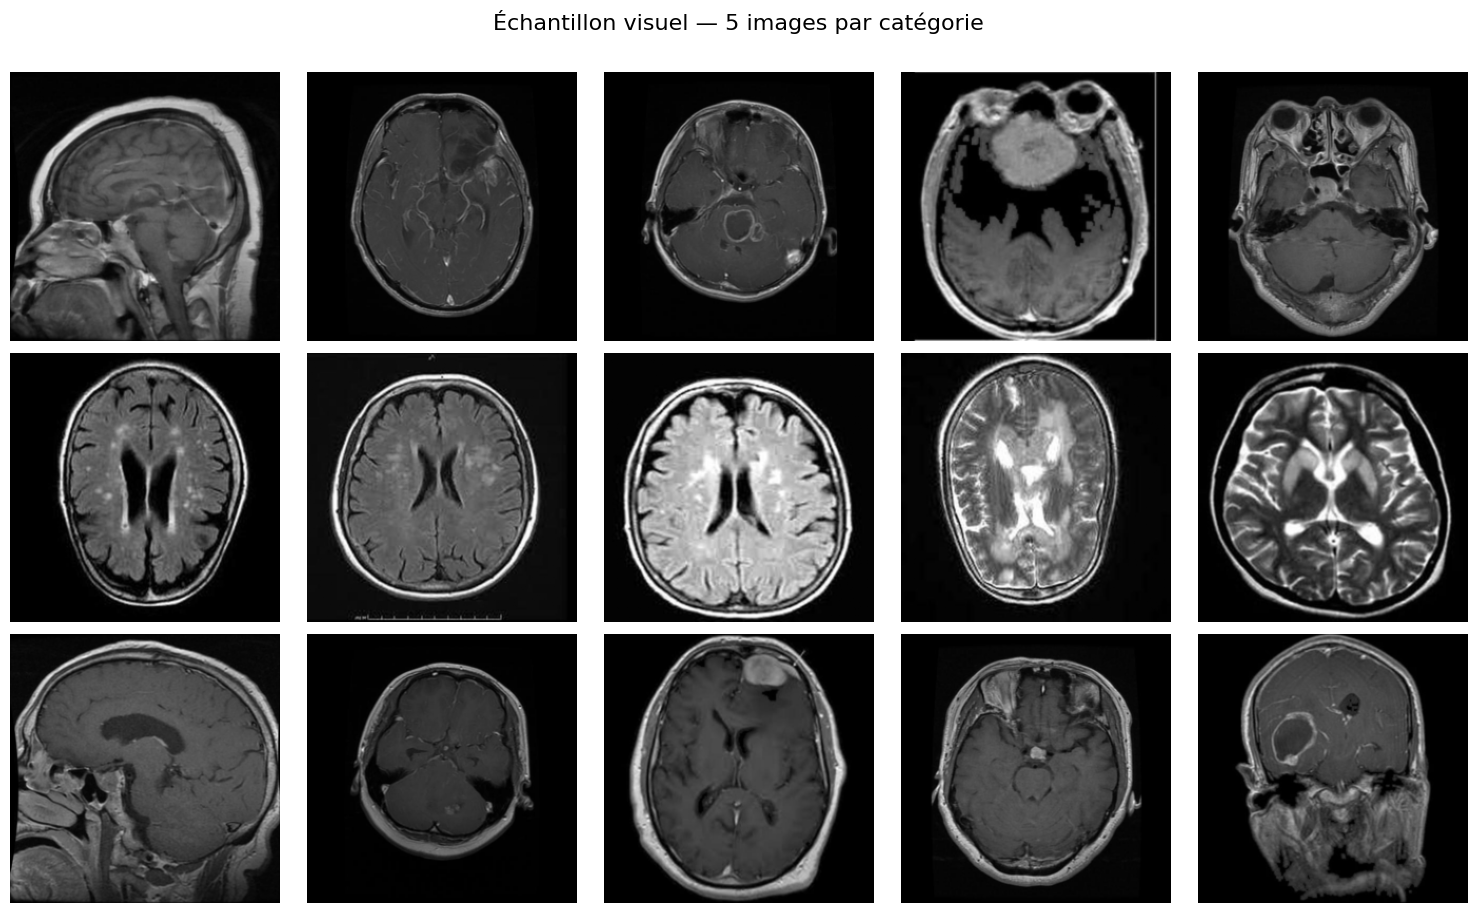


✓ Figure sauvegardée dans doc/dataset_preview/echantillon_visuel_etape1.png


In [8]:
# Échantillon visuel via torchvision
NB_EXEMPLES = 5

# --- Images labellisées via ImageFolder ---
transform_display = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

dataset_labelled = ImageFolder(
    root=str(DATA_ROOT / "avec_labels"),
    transform=transform_display,
)
class_names = dataset_labelled.classes  # ['cancer', 'normal']
print(f"Classes détectées par ImageFolder : {class_names}")
print(f"Nombre d'images labellisées : {len(dataset_labelled)}")

# Sélectionner NB_EXEMPLES par classe
indices_par_classe = {c: [] for c in range(len(class_names))}
for idx, (_, label) in enumerate(dataset_labelled.samples):
    if len(indices_par_classe[label]) < NB_EXEMPLES:
        indices_par_classe[label].append(idx)

# --- Images sans label (chargement manuel) ---
fichiers_sans_label = sorted(DIR_SANS_LABEL.iterdir())[:NB_EXEMPLES]
images_sans_label = []
for f in fichiers_sans_label:
    img = Image.open(f).convert("RGB")
    images_sans_label.append(transform_display(img))

# --- Affichage ---
fig, axes = plt.subplots(3, NB_EXEMPLES, figsize=(3 * NB_EXEMPLES, 9))

categories = list(class_names) + ["sans_label"]
for row, cat in enumerate(categories):
    if cat == "sans_label":
        imgs = images_sans_label
    else:
        class_idx = class_names.index(cat)
        imgs = [dataset_labelled[i][0] for i in indices_par_classe[class_idx]]

    for col in range(NB_EXEMPLES):
        ax = axes[row, col]
        img_np = imgs[col].permute(1, 2, 0).numpy()
        ax.imshow(img_np, cmap="gray" if img_np.shape[2] == 1 else None)
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(cat, fontsize=14, rotation=0, labelpad=80, va="center")

fig.suptitle("Échantillon visuel — 5 images par catégorie", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("doc/dataset_preview/echantillon_visuel_etape1.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✓ Figure sauvegardée dans doc/dataset_preview/echantillon_visuel_etape1.png")

## Synthèse d'observations

### Ce qui est propre

- Toutes les 1 506 images sont lisibles et non corrompues
- La résolution est homogène (512×512) sur l'ensemble du dataset
- Le format est uniformément JPEG
- Le mode couleur est uniformément RGB (3 canaux) — pas de mélange avec des images en niveaux de gris (L)
- Les noms de fichiers sont uniques entre les dossiers — aucun doublon
- La structure de dossiers fournit une labellisation claire pour les 100 images annotées

### Ce qui est à noter

- L'écart de 6 images non étiquetées par rapport à l'énoncé (1 406 vs 1 400 annoncées) est mineur mais documenté
- Le courriel de mission mentionne le format PNG, mais les fichiers sont en JPEG — le fichier descriptif du dataset confirme le JPEG
- Le déséquilibre est marqué : seulement 100 images labellisées pour 1 406 non labellisées (~6,6 % de labels) — c'est précisément le contexte qui justifie une approche semi-supervisée

### Implications pour l'étape 2

- **Prétraitement** : toutes les images sont déjà en RGB, pas de conversion de mode nécessaire
- **Extraction de features** : les images sont en 512×512, je les redimensionnerai au format attendu par le modèle pré-entraîné (ex. 224×224 pour ResNet50)
- **Pas d'anomalie bloquante** : le dataset est propre et exploitable en l'état pour l'étape suivante

## Definition of done — Validation

- [x] J'ai un tableau récapitulatif des sous-dossiers et du nombre d'images
- [x] J'ai vérifié que toutes les images sont lisibles (aucune corrompue)
- [x] J'ai vérifié résolution, format et canaux sur l'intégralité du dataset
- [x] J'ai vérifié l'absence de doublons entre dossiers
- [x] J'ai documenté les écarts entre l'énoncé et le dataset réel
- [x] J'ai au moins une visualisation d'exemples par catégorie (via torchvision)
- [x] J'ai rédigé des observations claires pour préparer l'étape 2